Step 1: Dataset Selection & Class Imbalance Visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("/content/creditcard.csv")

In [4]:
print(df.isnull().sum())
df.head()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
total       = len(df)
fraud_count = int(df["Class"].sum())
legit_count = total - fraud_count
fraud_pct   = fraud_count / total * 100
legit_pct   = legit_count / total * 100
ratio       = legit_count / fraud_count


print("        CLASS IMBALANCE SUMMARY")
print(f"  Total Samples        : {total:,}")
print(f"  Legitimate (class 0) : {legit_count:,}   ({legit_pct:.2f}%)")
print(f"  Fraud      (class 1) : {fraud_count:,}     ({fraud_pct:.4f}%)")
print(f"  Imbalance Ratio      : {ratio:.0f} : 1  (Legit : Fraud)")
print(f"  Samples to Generate  : {legit_count - fraud_count:,}")
print("Dataset is HIGHLY IMBALANCED")

        CLASS IMBALANCE SUMMARY
  Total Samples        : 11,959
  Legitimate (class 0) : 11,907   (99.57%)
  Fraud      (class 1) : 52     (0.4348%)
  Imbalance Ratio      : 229 : 1  (Legit : Fraud)
  Samples to Generate  : 11,855
Dataset is HIGHLY IMBALANCED


In [6]:
#summary table
summary_df = pd.DataFrame({
    "Class":       ["Legitimate (0)", "Fraud (1)", "Total"],
    "Count":       [legit_count, fraud_count, total],
    "Percentage":  [f"{legit_pct:.2f}%", f"{fraud_pct:.4f}%", "100%"],
    "Mean Amount": [
        f"${df[df['Class']==0]['Amount'].mean():.2f}",
        f"${df[df['Class']==1]['Amount'].mean():.2f}",
        f"${df['Amount'].mean():.2f}"
    ],
    "Max Amount": [
        f"${df[df['Class']==0]['Amount'].max():.2f}",
        f"${df[df['Class']==1]['Amount'].max():.2f}",
        f"${df['Amount'].max():.2f}"
    ]
})
print(summary_df.to_string(index=False))

         Class  Count Percentage Mean Amount Max Amount
Legitimate (0)  11907     99.57%      $62.20   $7712.43
     Fraud (1)     52    0.4348%      $97.72   $1809.68
         Total  11959       100%      $62.35   $7712.43


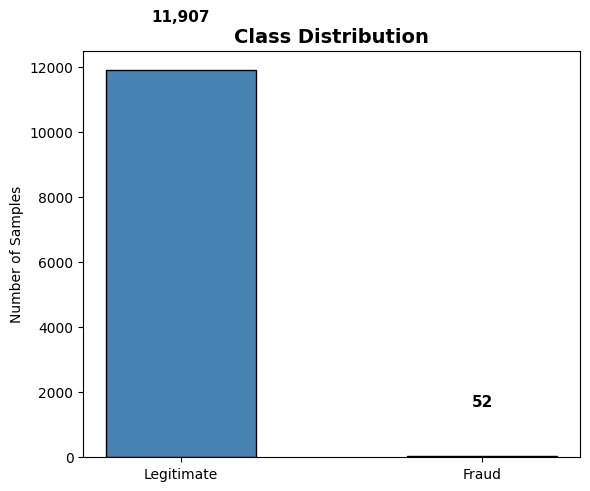

In [7]:
# Plot 1: Bar Chart
plt.figure(figsize=(6, 5))
bars = plt.bar(["Legitimate", "Fraud"], [legit_count, fraud_count],
               color=["steelblue", "tomato"], edgecolor="black", width=0.5)
for bar, val in zip(bars, [legit_count, fraud_count]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
             f"{val:,}", ha="center", fontsize=11, fontweight="bold")
plt.title("Class Distribution", fontsize=14, fontweight="bold")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("plot1_bar_chart.png", dpi=150)
plt.show()

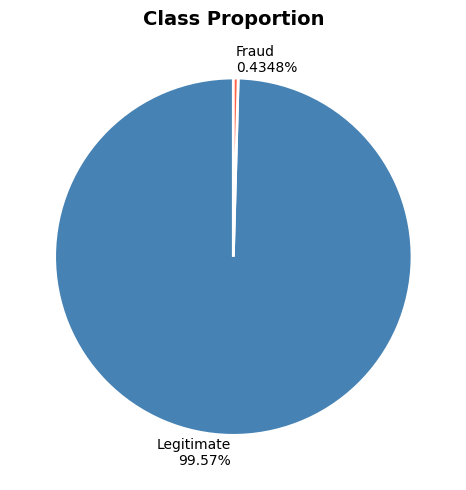

In [8]:
# Plot 2: Pie Chart
plt.figure(figsize=(6, 5))
plt.pie([legit_count, fraud_count],
        labels=[f"Legitimate\n{legit_pct:.2f}%", f"Fraud\n{fraud_pct:.4f}%"],
        colors=["steelblue", "tomato"],
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2))
plt.title("Class Proportion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot2_pie_chart.png", dpi=150)
plt.show()

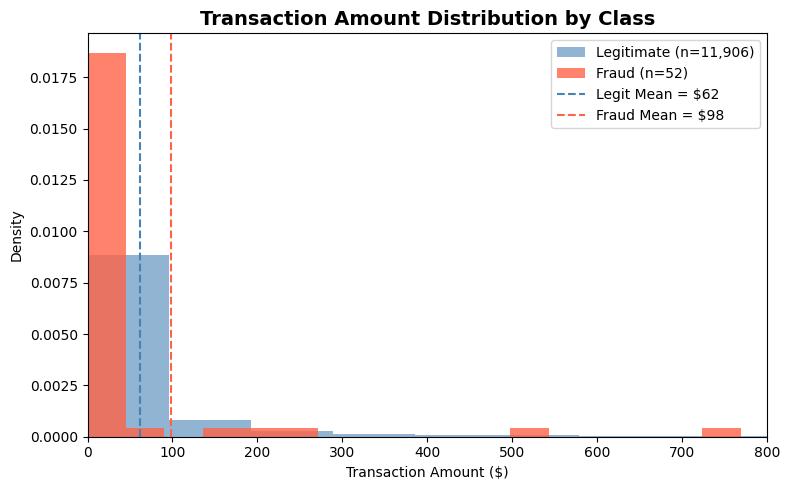

In [9]:
# Plot 3: Transaction Amount Distribution
# Plot 4: Transaction Amount Distribution

fraud_df = df[df["Class"] == 1]
legit_df = df[df["Class"] == 0]
legit_count = len(legit_df)
fraud_count = len(fraud_df)
# ───────────────────────────────────────────

plt.figure(figsize=(8, 5))
plt.hist(legit_df["Amount"], bins=80, color="steelblue", alpha=0.6,
         label=f"Legitimate (n={legit_count:,})", density=True)
plt.hist(fraud_df["Amount"], bins=40, color="tomato", alpha=0.8,
         label=f"Fraud (n={fraud_count})", density=True)
plt.axvline(legit_df["Amount"].mean(), color="steelblue", linestyle="--",
            linewidth=1.5, label=f"Legit Mean = ${legit_df['Amount'].mean():.0f}")
plt.axvline(fraud_df["Amount"].mean(), color="tomato", linestyle="--",
            linewidth=1.5, label=f"Fraud Mean = ${fraud_df['Amount'].mean():.0f}")
plt.title("Transaction Amount Distribution by Class", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Density")
plt.xlim(0, 800)
plt.legend()
plt.tight_layout()
plt.savefig("plot4_amount_distribution.png", dpi=150)
plt.show()

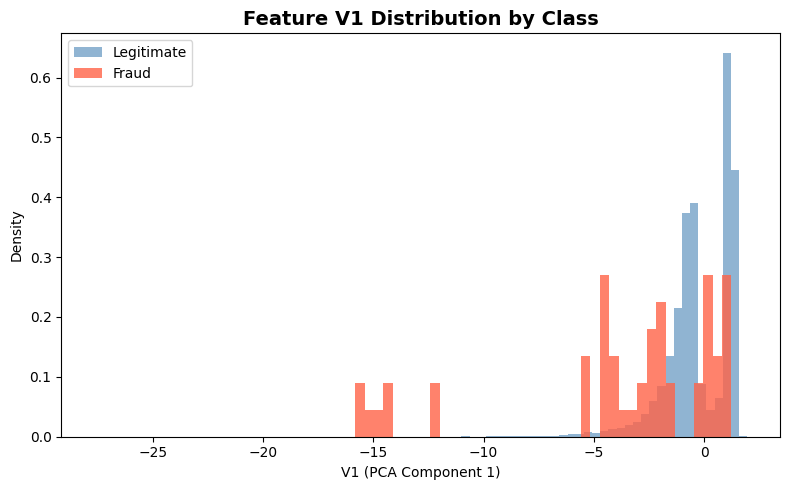

In [10]:
# Plot 4: V1 Feature Distribution
plt.figure(figsize=(8, 5))
plt.hist(legit_df["V1"], bins=80, color="steelblue", alpha=0.6,
         density=True, label="Legitimate")
plt.hist(fraud_df["V1"], bins=40, color="tomato", alpha=0.8,
         density=True, label="Fraud")
plt.title("Feature V1 Distribution by Class", fontsize=14, fontweight="bold")
plt.xlabel("V1 (PCA Component 1)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_v1_distribution.png", dpi=150)
plt.show()

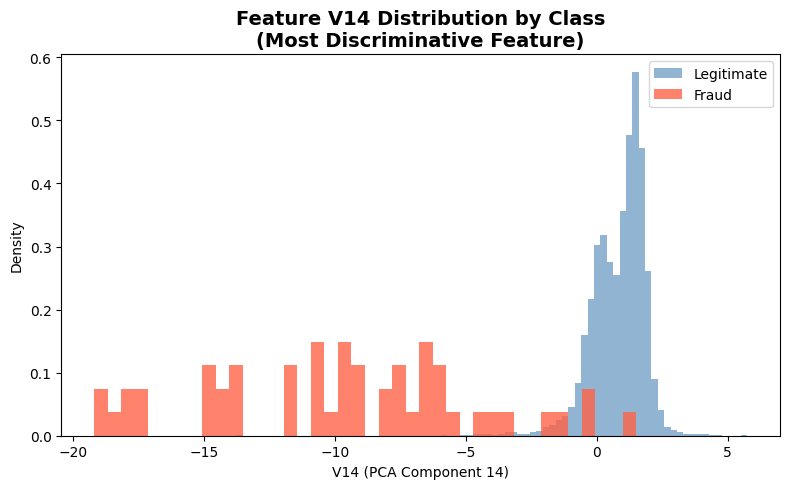

In [11]:
# Plot 5: V14 Feature Distribution
plt.figure(figsize=(8, 5))
plt.hist(legit_df["V14"], bins=80, color="steelblue", alpha=0.6,
         density=True, label="Legitimate")
plt.hist(fraud_df["V14"], bins=40, color="tomato", alpha=0.8,
         density=True, label="Fraud")
plt.title("Feature V14 Distribution by Class\n(Most Discriminative Feature)",
          fontsize=14, fontweight="bold")
plt.xlabel("V14 (PCA Component 14)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_v14_distribution.png", dpi=150)
plt.show()

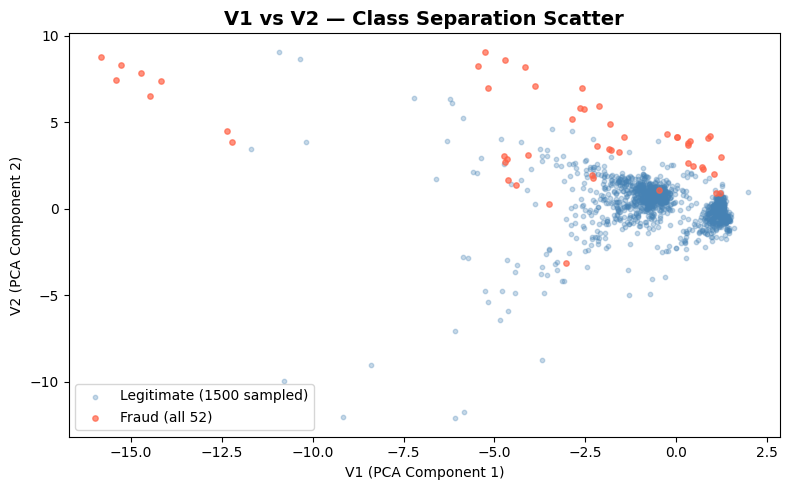

In [12]:
# Plot 6: Scatter V1 vs V2
plt.figure(figsize=(8, 5))
sample_idx = np.random.choice(len(legit_df), 1500, replace=False)
plt.scatter(legit_df["V1"].iloc[sample_idx], legit_df["V2"].iloc[sample_idx],
            color="steelblue", alpha=0.3, s=10, label="Legitimate (1500 sampled)")
plt.scatter(fraud_df["V1"], fraud_df["V2"],
            color="tomato", alpha=0.7, s=15, label=f"Fraud (all {fraud_count})")
plt.title("V1 vs V2 — Class Separation Scatter", fontsize=14, fontweight="bold")
plt.xlabel("V1 (PCA Component 1)")
plt.ylabel("V2 (PCA Component 2)")
plt.legend()
plt.tight_layout()
plt.savefig("plot6_scatter_v1_v2.png", dpi=150)
plt.show()

Step 2: GAN Implementation

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── ALWAYS start by reloading the raw CSV ──────────────────
df = pd.read_csv("creditcard.csv")

# ── Drop NaN rows ───────────────────────────────────────────
df = df.dropna()
print(f"Shape after dropping NaN: {df.shape}")

# ── Preprocess ──────────────────────────────────────────────
df["NormAmount"] = StandardScaler().fit_transform(df[["Amount"]])
df = df.drop(columns=["Time", "Amount"])

# ── Verify ──────────────────────────────────────────────────
print(f"Columns         : {list(df.columns[:5])} ...")
print(f"Class values    : {df['Class'].unique()}")
print(f"Remaining NaN   : {df.isnull().sum().sum()}")

x = df.drop(columns=["Class"]).values.astype(np.float32)
y = df["Class"].values.astype(np.float32)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

X_minority = x_train[y_train == 1]
X_majority = x_train[y_train == 0]

n_features     = x.shape[1]
samples_to_gen = len(X_majority) - len(X_minority)
LATENT_DIM     = 64
EPOCHS_GAN     = 300
BATCH_SIZE     = 64
LR             = 0.0002

print(f"\nFeatures        : {n_features}")
print(f"Minority samples: {len(X_minority)}")
print(f"Need to generate: {samples_to_gen:,} fake fraud samples")

Shape after dropping NaN: (45645, 31)
Columns         : ['V1', 'V2', 'V3', 'V4', 'V5'] ...
Class values    : [0. 1.]
Remaining NaN   : 0

Features        : 29
Minority samples: 114
Need to generate: 36,288 fake fraud samples


In [15]:
# Hyperparameters
LATENT_DIM = 100
LR = 0.0002
BATCH_SIZE = 64
EPOCHS_GAN = 300

# Number of features in your dataset
n_features = X_minority.shape[1]


# Generator
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, n_features)
        )

    def forward(self, z):
        return self.net(z)


# Discriminator
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# Training Function
def train_vanilla_gan(x_minority):

    # Convert data to tensor
    x_minority = torch.tensor(x_minority, dtype=torch.float32)

    # Create dataloader
    dataset = TensorDataset(x_minority)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Initialize models
    G = Generator()
    D = Discriminator()

    # Optimizers
    opt_G = torch.optim.Adam(G.parameters(), lr=LR)
    opt_D = torch.optim.Adam(D.parameters(), lr=LR)

    # Loss function
    criterion = nn.BCELoss()


    # Training Loop
    for epoch in range(EPOCHS_GAN):

        for (real,) in loader:

            batch_size = real.size(0)


            # Train Discriminator
            z = torch.randn(batch_size, LATENT_DIM)
            fake = G(z).detach()
            real_labels = torch.ones(batch_size, 1)
            fake_labels = torch.zeros(batch_size, 1)
            real_loss = criterion(D(real), real_labels)
            fake_loss = criterion(D(fake), fake_labels)
            loss_D = real_loss + fake_loss

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()


            # Train Generator
            z = torch.randn(batch_size, LATENT_DIM)
            generated = G(z)
            loss_G = criterion(D(generated), real_labels)

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        # Print progress
        if (epoch + 1) % 50 == 0:
            print(
                f"[Vanilla GAN] Epoch {epoch+1}/{EPOCHS_GAN} "
                f"| D_loss: {loss_D.item():.4f} "
                f"| G_loss: {loss_G.item():.4f}"
            )

    return G


# Train GAN
print("\n── Training Vanilla GAN ──")
vanilla_G = train_vanilla_gan(X_minority)


── Training Vanilla GAN ──
[Vanilla GAN] Epoch 50/300 | D_loss: 1.0684 | G_loss: 0.5985
[Vanilla GAN] Epoch 100/300 | D_loss: 1.0424 | G_loss: 0.9166
[Vanilla GAN] Epoch 150/300 | D_loss: 0.6201 | G_loss: 1.3690
[Vanilla GAN] Epoch 200/300 | D_loss: 0.5606 | G_loss: 1.5841
[Vanilla GAN] Epoch 250/300 | D_loss: 0.7137 | G_loss: 1.2773
[Vanilla GAN] Epoch 300/300 | D_loss: 0.9062 | G_loss: 1.1725


In [16]:
# 2. WGAN (Wasserstein GAN)
class WGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, n_features)
        )
    def forward(self, z):
        return self.net(z)

class WCritic(nn.Module):        # No sigmoid — outputs raw score
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128),        nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)

def train_wgan(X_minority, n_critic=5, clip=0.01):
    G = WGenerator()
    C = WCritic()
    opt_G = torch.optim.RMSprop(G.parameters(), lr=0.00005)
    opt_C = torch.optim.RMSprop(C.parameters(), lr=0.00005)

    data = TensorDataset(torch.tensor(X_minority))
    loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True)

    for epoch in range(EPOCHS_GAN):
        for (real,) in loader:
            # Train Critic n_critic times
            for _ in range(n_critic):
                z = torch.randn(len(real), LATENT_DIM)
                fake = G(z).detach()
                loss_C = -(C(real).mean() - C(fake).mean())  # Wasserstein loss
                opt_C.zero_grad(); loss_C.backward(); opt_C.step()
                # Weight clipping
                for p in C.parameters():
                    p.data.clamp_(-clip, clip)

            # Train Generator
            z = torch.randn(len(real), LATENT_DIM)
            loss_G = -C(G(z)).mean()
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        if (epoch+1) % 50 == 0:
            print(f"  [WGAN] Epoch {epoch+1}/{EPOCHS_GAN} | C_loss: {loss_C.item():.4f} | G_loss: {loss_G.item():.4f}")

    return G

print("\n── Training WGAN ──")
wgan_G = train_wgan(X_minority)



── Training WGAN ──
  [WGAN] Epoch 50/300 | C_loss: -0.9109 | G_loss: -0.4209
  [WGAN] Epoch 100/300 | C_loss: -0.3145 | G_loss: -0.7202
  [WGAN] Epoch 150/300 | C_loss: -0.1021 | G_loss: -0.1923
  [WGAN] Epoch 200/300 | C_loss: -0.0799 | G_loss: -0.0010
  [WGAN] Epoch 250/300 | C_loss: -0.0480 | G_loss: -0.0047
  [WGAN] Epoch 300/300 | C_loss: -0.0449 | G_loss: 0.0026


In [17]:
# 3. Generate Synthetic Samples & Balance Dataset
def generate_samples(generator, n_samples):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, LATENT_DIM)
        fake = generator(z).numpy()
    return fake

# Generate fake fraud samples
vanilla_fake = generate_samples(vanilla_G, samples_to_gen)
wgan_fake    = generate_samples(wgan_G,    samples_to_gen)

# Build 3 versions of the training set
# Version 1: Original imbalanced
X_train_orig = x_train
y_train_orig = y_train

# Version 2: Balanced with Vanilla GAN
X_train_vanilla = np.vstack([x_train, vanilla_fake])
y_train_vanilla = np.concatenate([y_train, np.ones(samples_to_gen)])

# Version 3: Balanced with WGAN
X_train_wgan = np.vstack([x_train, wgan_fake])
y_train_wgan = np.concatenate([y_train, np.ones(samples_to_gen)])

print(f"\nDataset sizes:")
print(f"  Original  : {len(X_train_orig):,} samples")
print(f"  Vanilla   : {len(X_train_vanilla):,} samples")
print(f"  WGAN      : {len(X_train_wgan):,} samples")


Dataset sizes:
  Original  : 36,516 samples
  Vanilla   : 72,804 samples
  WGAN      : 72,804 samples


Data Augmentation & Classification

In [18]:
# 4. MLP Classifier
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),         nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

def train_classifier(X_tr, y_tr, epochs=50):
    model = MLP()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    dataset = TensorDataset(X_t, y_t)
    loader  = DataLoader(dataset, batch_size=256, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

    return model

def evaluate(model, X_te, y_te, label):
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_te, dtype=torch.float32))
        preds = (preds.numpy() > 0.5).astype(int).flatten()
    print(f"\n{'='*50}")
    print(f" Results — {label}")
    print(f"{'='*50}")
    print(classification_report(y_te, preds, target_names=["Legitimate", "Fraud"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_te, preds))

Train & Evaluate All 3 Classifiers

In [19]:
print("\n── Training Classifier on Original Data ──")

clf_orig = train_classifier(X_train_orig, y_train_orig)

evaluate(
    clf_orig,
    x_test,
    y_test,
    "Original Imbalanced Dataset"
)

# =========================================

print("\n── Training Classifier on Vanilla GAN Balanced Data ──")

clf_vanilla = train_classifier(
    X_train_vanilla,
    y_train_vanilla
)

evaluate(
    clf_vanilla,
    x_test,
    y_test,
    "Balanced with Vanilla GAN"
)

# =========================================

print("\n── Training Classifier on WGAN Balanced Data ──")

clf_wgan = train_classifier(
    X_train_wgan,
    y_train_wgan
)

evaluate(
    clf_wgan,
    x_test,
    y_test,
    "Balanced with WGAN"
)


── Training Classifier on Original Data ──

 Results — Original Imbalanced Dataset
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      9101
       Fraud       0.67      0.86      0.75        28

    accuracy                           1.00      9129
   macro avg       0.83      0.93      0.87      9129
weighted avg       1.00      1.00      1.00      9129

Confusion Matrix:
[[9089   12]
 [   4   24]]

── Training Classifier on Vanilla GAN Balanced Data ──

 Results — Balanced with Vanilla GAN
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      9101
       Fraud       0.78      0.89      0.83        28

    accuracy                           1.00      9129
   macro avg       0.89      0.95      0.92      9129
weighted avg       1.00      1.00      1.00      9129

Confusion Matrix:
[[9094    7]
 [   3   25]]

── Training Classifier on WGAN Balanced Data ──

 Results — Balanced with WGA


=== Performance Comparison Table ===

       Dataset  Precision  Recall  F1-Score
0     Original       0.67    0.86      0.75
1  Vanilla GAN       0.78    0.89      0.83
2         WGAN       0.96    0.89      0.93


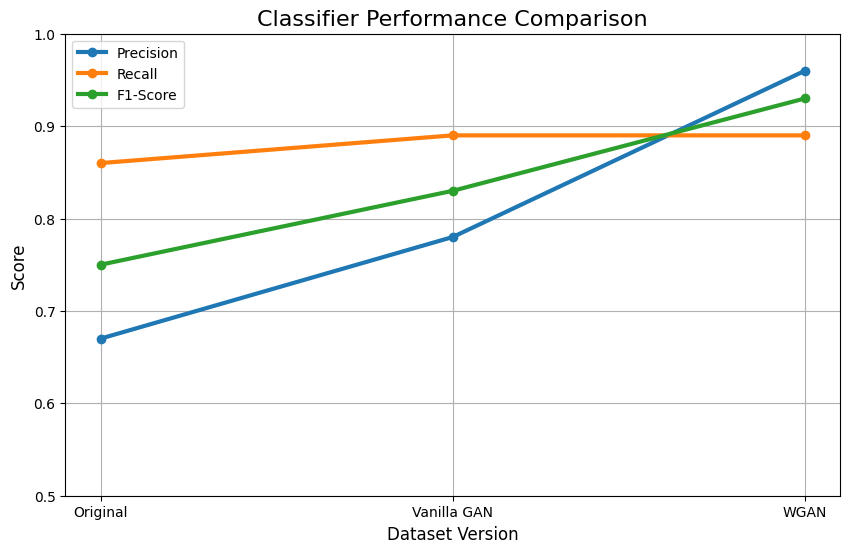

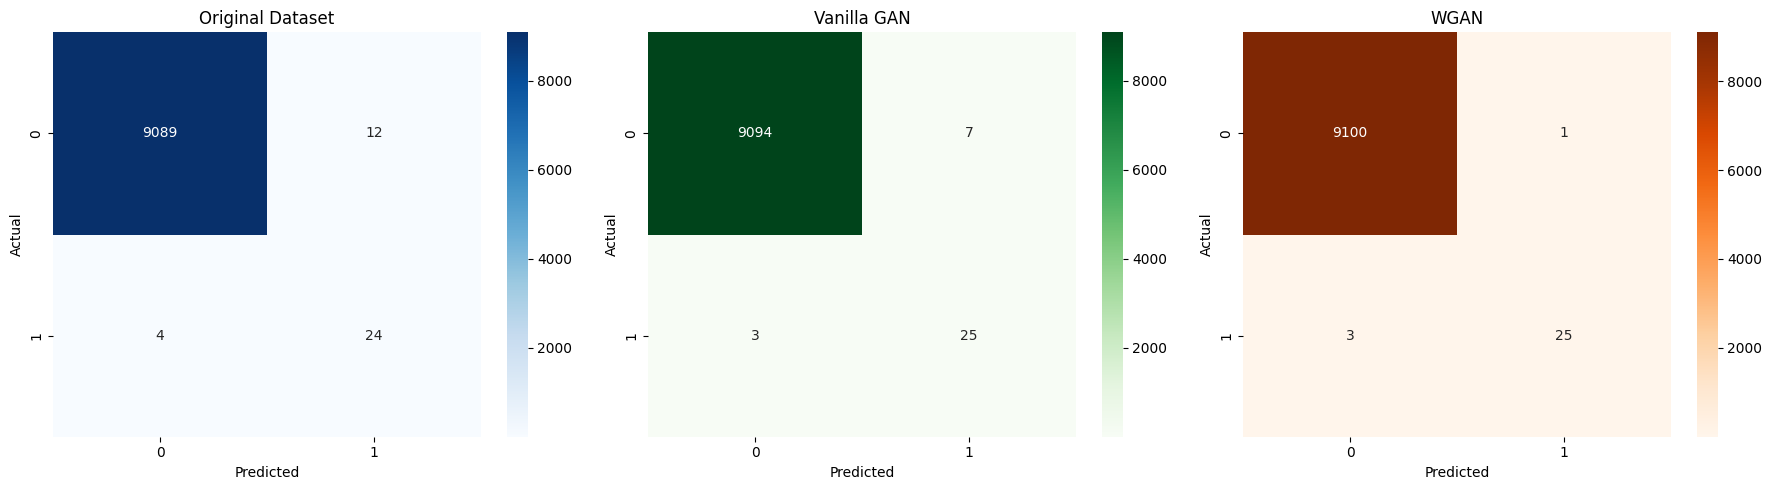

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# Store Results
# =========================================

results = pd.DataFrame({
    "Dataset": [
        "Original",
        "Vanilla GAN",
        "WGAN"
    ],

    "Precision": [
        0.67,
        0.78,
        0.96
    ],

    "Recall": [
        0.86,
        0.89,
        0.89
    ],

    "F1-Score": [
        0.75,
        0.83,
        0.93
    ]
})

# =========================================
# Display Results Table
# =========================================

print("\n=== Performance Comparison Table ===\n")
print(results)

# =========================================
# Plot Metric Comparison
# =========================================

plt.figure(figsize=(10,6))

plt.plot(
    results["Dataset"],
    results["Precision"],
    marker='o',
    linewidth=3,
    label='Precision'
)

plt.plot(
    results["Dataset"],
    results["Recall"],
    marker='o',
    linewidth=3,
    label='Recall'
)

plt.plot(
    results["Dataset"],
    results["F1-Score"],
    marker='o',
    linewidth=3,
    label='F1-Score'
)

plt.title("Classifier Performance Comparison", fontsize=16)

plt.xlabel("Dataset Version", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.ylim(0.5, 1.0)

plt.grid(True)
plt.legend()

plt.show()

# =========================================
# Confusion Matrices
# =========================================

cm_original = [
    [9089, 12],
    [4, 24]
]

cm_vanilla = [
    [9094, 7],
    [3, 25]
]

cm_wgan = [
    [9100, 1],
    [3, 25]
]

# =========================================
# Plot Confusion Matrices
# =========================================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.heatmap(
    cm_original,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Original Dataset")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_vanilla,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title("Vanilla GAN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    cm_wgan,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[2]
)

axes[2].set_title("WGAN")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()